<a href="https://colab.research.google.com/github/vickyvillu2021/vigneshvillupuram_feburary_training/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

import shap
import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Read dataset
df = pd.read_csv(file_name)

print("✅ Dataset Loaded")
print("Shape:", df.shape)
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
✅ Dataset Loaded
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Drop customerID safely
df.drop(columns=['customerID'], errors='ignore', inplace=True)

# Fix TotalCharges
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("✅ Cleaning Done")

✅ Cleaning Done


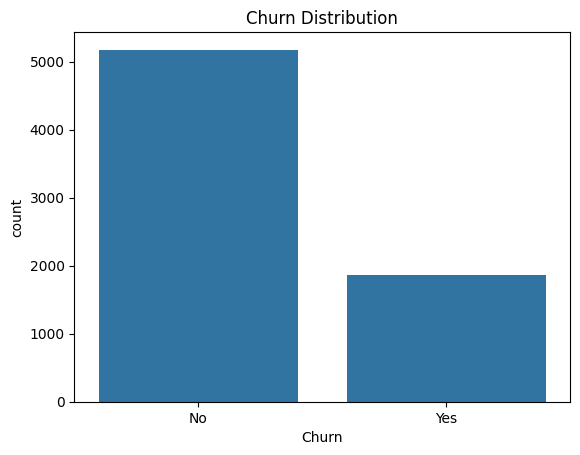

In [5]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [6]:
df = pd.get_dummies(df, drop_first=True)
print("✅ Encoding Done")

✅ Encoding Done


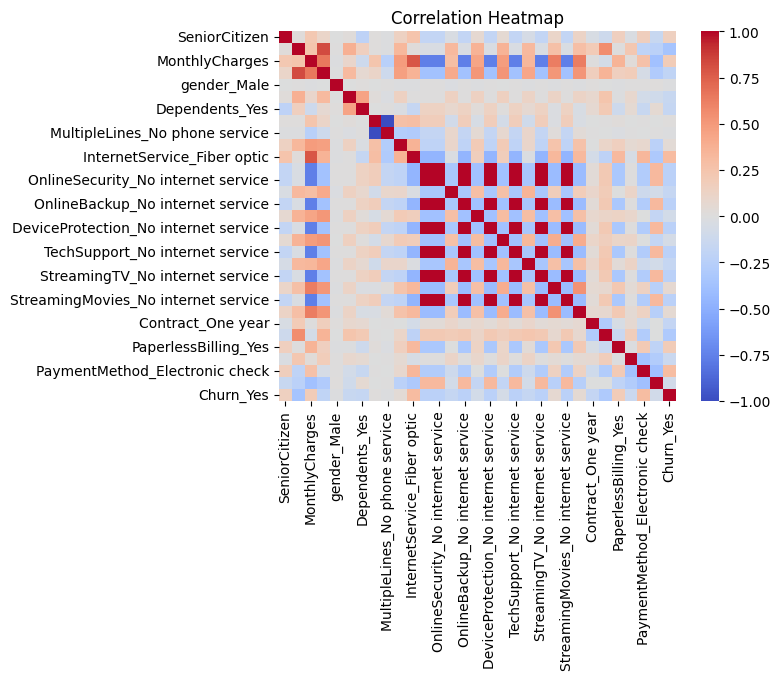

In [7]:
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [8]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['ContractValue'] = df['MonthlyCharges'] * df['tenure']

In [9]:
# After encoding → target becomes Churn_Yes
target_col = 'Churn_Yes'

X = df.drop(columns=[target_col])
y = df[target_col]

print("✅ Target set:", target_col)

✅ Target set: Churn_Yes


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200),
    "SVM": SVC(probability=True)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print(classification_report(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, prob))


Logistic
              precision    recall  f1-score   support

       False       0.85      0.82      0.83      1035
        True       0.54      0.59      0.57       374

    accuracy                           0.76      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.76      0.76      1409

ROC-AUC: 0.8200728512748974

RandomForest
              precision    recall  f1-score   support

       False       0.85      0.84      0.84      1035
        True       0.56      0.58      0.57       374

    accuracy                           0.77      1409
   macro avg       0.70      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409

ROC-AUC: 0.8201258105350177

SVM
              precision    recall  f1-score   support

       False       0.86      0.83      0.85      1035
        True       0.58      0.64      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73

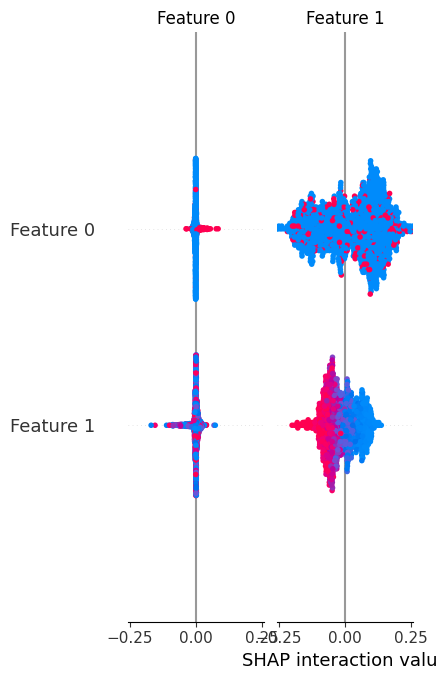

In [17]:
import shap

# Train model again (important)
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Use TreeExplainer explicitly
explainer = shap.TreeExplainer(model)

# Disable strict check
shap_values = explainer.shap_values(X_test, check_additivity=False)

# Plot
shap.summary_plot(shap_values, X_test)

In [18]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.7799858055358411
